# Financial Fraud Detection Model
An executed, reproducible walkthrough of the supplied datasets and trained results. Run from the extracted project folder. See `train.py` and `src/` for the full reusable implementation.

**Scope:** local academic prototype. Models on two sources perform near baseline; no production accuracy claim is made.

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    raise RuntimeError('Open this notebook from Financial_Fraud_Detection')
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, joblib
from src.data import CONFIG, load_data, features
from src.models import score
print('Datasets:', ', '.join(CONFIG))

Datasets: bank, synthetic, credit_card


## 1. Source audit
The datasets have distinct schemas and are modeled independently. Unreviewed bank rows are excluded, not marked safe.

In [2]:
audits=[]
for key in CONFIG:
    df, audit=load_data(key)
    audits.append({'dataset':key, **audit})
print(pd.DataFrame(audits).to_string(index=False))

    dataset                       source  raw_rows  excluded_unreviewed  duplicate_rows_removed   rows  fraud_count  fraud_rate  missing_cells_raw
       bank       bank_transactions.xlsx     10127                    2                       0  10125           68    0.006716                 58
  synthetic   synthetic_transactions.csv     50000                    0                       0  50000        16067    0.321340                  0
credit_card credit_card_transactions.csv    100000                    0                       0 100000         1000    0.010000                  0


## 2. Explicit features
Only allowlisted, assumed pre-event inputs are used. Labels and label copies cannot leak into X. Calendar/log features are deterministic; learned preprocessing fits training data only.

In [3]:
for key in CONFIG:
    df,_=load_data(key)
    x=features(df,key)
    print(key, ':', ', '.join(x.columns))

bank : amount, oldbalanceOrg, oldbalanceDest, type, branch, Acct type, Time of day, month, weekday, log_amount
synthetic : Transaction_Amount, Card_Age, Transaction_Type, Device_Type, Location, Merchant_Category, Card_Type, month, weekday, log_amount
credit_card : Amount, TransactionType, Location, month, weekday, log_amount


## 3. Split evidence
Synthetic transactions are partitioned by user; other sources use stratified random splits. Random benchmarks are not a substitute for future-time evaluation.

In [4]:
for key in CONFIG:
    p=ROOT/'artifacts'/key
    audit=json.loads((p/'audit.json').read_text())
    split=pd.read_csv(p/'split_manifest.csv')
    print(key, audit['split_method'])
    print(split.groupby('split').agg(rows=('row_id','size'), fitted_rows=('used_for_fit','sum')).to_string())

bank 60/20/20 stratified random benchmark; not a future-time backtest
            rows  fitted_rows
split                        
test        2025            0
train       6075         6075
validation  2025            0
synthetic 60/20/20 approximate user-group split (no overlapping User_ID)
             rows  fitted_rows
split                         
test         9929            0
train       29863        20000
validation  10208            0
credit_card 60/20/20 stratified random benchmark; not a future-time backtest
             rows  fitted_rows
split                         
test        20000            0
train       60000        20000
validation  20000            0


## 4. Algorithms and training
The full run includes six classifiers, a dummy baseline, three experimental regressors and three anomaly methods. The neural classifier uses 64→32→16 hidden units; the reconstruction autoencoder uses 32→8→32. Regressor/anomaly scores are not probabilities.

To retrain from this folder, run `python train.py --dataset all` in a terminal, then `python scripts/build_report.py`. Training is explicit so reopening this notebook does not silently replace saved models.

In [5]:
from src.models import candidates
for name,(kind,model) in candidates().items():
    print(name, '|', kind, '|', model)

Dummy baseline | classifier | DummyClassifier()
Logistic Regression | classifier | LogisticRegression(class_weight='balanced', max_iter=700, random_state=42)
KNN | classifier | KNeighborsClassifier(n_jobs=2, n_neighbors=15, weights='distance')
Decision Tree | classifier | DecisionTreeClassifier(class_weight='balanced', max_depth=7,
                       min_samples_leaf=10, random_state=42)
Random Forest | classifier | RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, n_estimators=120, n_jobs=2,
                       random_state=42)
Gradient Boosting | classifier | HistGradientBoostingClassifier(class_weight='balanced', l2_regularization=2,
                               max_iter=120, max_leaf_nodes=15,
                               random_state=42)
Deep Neural Network | classifier | MLPClassifier(batch_size=256, early_stopping=True,
              hidden_layer_sizes=(64, 32, 16), max_iter=100,
              n_iter_no_change=12,

## 5. Validation-selected model comparison
Primary classifier selection uses validation average precision. Thresholds maximize validation F2. Test rows are used only after these choices are frozen.

In [6]:
for key in CONFIG:
    m=pd.read_csv(ROOT/'artifacts'/key/'model_metrics.csv')
    print('\n'+key.upper())
    print(m[['model','fit_rows','val_average_precision','test_average_precision','test_precision','test_recall']].to_string(index=False))


BANK
                model  fit_rows  val_average_precision  test_average_precision  test_precision  test_recall
    Gradient Boosting      6075               0.741960                0.772313        0.800000     0.615385
        Random Forest      6075               0.287556                0.417409        0.357143     0.769231
        Decision Tree      6075               0.240514                0.224934        0.277778     0.384615
  Logistic Regression      6075               0.174771                0.135858        0.200000     0.538462
                  KNN      6075               0.127378                0.173930        0.357143     0.384615
                  SVR      5000               0.095255                0.138957        0.187500     0.230769
Polynomial Regression      6075               0.079672                0.136214        0.250000     0.307692
    Linear Regression      6075               0.053364                0.038908        0.033670     0.769231
          Autoencoder 

## 6. Summarize the measured results
Average precision is compared with test class prevalence. Similar values indicate little useful ranking improvement.

In [7]:
summary=pd.read_csv(ROOT/'reports'/'results_summary.csv')
print(summary.to_string(index=False))

    dataset   rows  frauds             model  test_rows  test_frauds  test_AP  AP_baseline  precision   recall   TP    FP  FN   TN  threshold
       bank  10125      68 Gradient Boosting       2025           13 0.772313     0.006420   0.800000 0.615385    8     2   5 2010   0.954322
  synthetic  50000   16067     Random Forest       9929         3186 0.315876     0.320878   0.320878 1.000000 3186  6743   0    0   0.290220
credit_card 100000    1000 Gradient Boosting      20000          200 0.011867     0.010000   0.010832 0.635000  127 11597  73 8203   0.421973


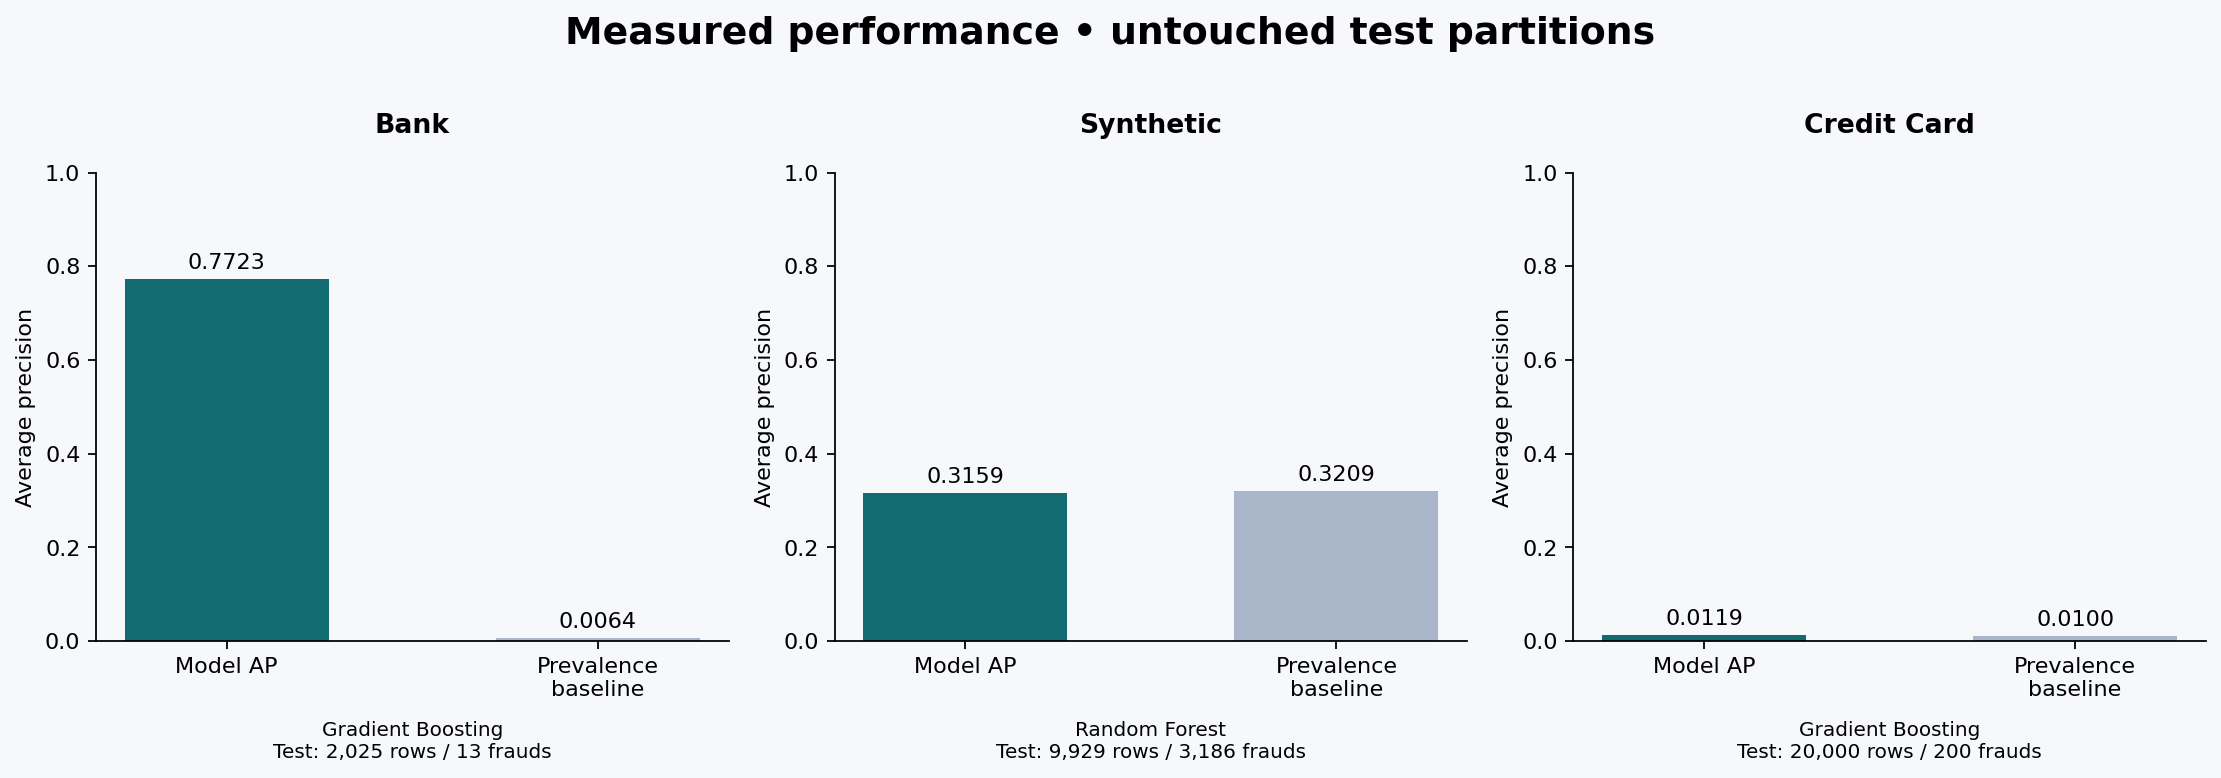

In [8]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "reports" / "evaluation.png")))

## 7. Reload and score held-out transactions
Inference uses the same serialized preprocessing as training. Extra columns, including labels, are not features.

In [9]:
key='bank'
b=joblib.load(ROOT/'artifacts'/key/'best_model.joblib')
test=pd.read_csv(ROOT/'artifacts'/key/'test_predictions.csv')
scores=score(b['model'],features(test.head(5),key),b['kind'])
print(pd.DataFrame({'risk_score':scores,'flagged':scores>=b['threshold'],'actual':test.label.head(5)}).to_string(index=False))
np.testing.assert_allclose(scores,test.risk_score.head(5),rtol=1e-6,atol=1e-9)
print('Serialized inference matches stored evaluation.')

 risk_score  flagged  actual
   0.000081    False       0
   0.000742    False       0
   0.000044    False       0
   0.000122    False       0
   0.000578    False       0
Serialized inference matches stored evaluation.


## 8. SQL ETL inspection
These tables contain the cleaned full sources. They are for analysis, not reported out-of-sample model performance.

In [10]:
import sqlite3
with sqlite3.connect(ROOT/'artifacts'/'fraud_detection.db') as con:
    for key in CONFIG:
        print(key,pd.read_sql_query(f'SELECT COUNT(*) AS rows, SUM(label) AS frauds FROM {key}_transactions',con).to_dict('records'))

bank [{'rows': 10125, 'frauds': 68}]
synthetic [{'rows': 50000, 'frauds': 16067}]
credit_card [{'rows': 100000, 'frauds': 1000}]


## 9. Interpretation and next steps
Bank: 8/13 test frauds detected with 2 false positives. Small positive counts and random splits limit generalization.

Synthetic and credit-card: near-baseline performance. F2 optimization produces excessive alerts; this is documented model weakness, not a successful operational detector.

Next: verify labels and feature timing; obtain past-only behavioral features; run temporal validation; calibrate and select cost-aware thresholds. Kafka/Spark, external alerts, graph models and online adaptation remain extensions.

Launch dashboard: `python -m streamlit run app.py`.